# TF vs PyTorch S-picker on real waveforms

Loads Keras **S** weights into TensorFlow `modelS` and `EQCCTModelS`, draws **6000-sample, 3-component** windows from **SeisBench** (TXED or STEAD: 100 Hz, `component_order="ZNE"`). Only traces with **both** catalog P and S picks are used; each window is centered on the **catalog S** time (clamped so the 6000-sample slice fits the trace).

The data cell builds **several windows** by re-shuffling the valid trace list with seeds `0 … N-1`; the next cell runs both S pickers and plots **one probability panel per seed** (TF, PT, catalog S).

Requires `seisbench`. If you see `No module named pkg_resources`, run `pip install 'setuptools>=69,<81'`.

**Optional:** save a PyTorch S checkpoint:

```bash
PYTHONPATH=. python -m validation.tf_pt_s_trace \
  --p-h5 ModelPS/test_trainer_024.h5 --s-h5 ModelPS/test_trainer_021.h5 \
  --skip-weights --skip-activations --save-model ModelPS/eqcct_model_s.pt
```

Use a kernel with TensorFlow, PyTorch, SeisBench, and this repo on `PYTHONPATH`. The model cell hides TensorFlow GPUs (same rationale as the P demo — see `parity_p_model.py` / layer trace notes).

In [1]:
from pathlib import Path
import os
import sys

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

P_H5 = REPO / "ModelPS" / "test_trainer_024.h5"
S_H5 = REPO / "ModelPS" / "test_trainer_021.h5"
PT_CKPT = REPO / "ModelPS" / "eqcct_model_s.pt"

print("REPO", REPO)
print("P_H5 exists", P_H5.is_file(), "S_H5 exists", S_H5.is_file())
print("PT_S_CKPT exists", PT_CKPT.is_file())

REPO /home/skevofilaxc/workspace/EQCCT_to_Seisbench
P_H5 exists True S_H5 exists True
PT_S_CKPT exists True


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import tensorflow as tf

try:
    tf.config.set_visible_devices([], "GPU")
except Exception:
    pass

from reference.predictor_tf import load_eqcct_model
from models.predictor_pt_p import EQCCTModelS
from conversion.loader import load_eqcct_model_s_weights

_, model_s_tf = load_eqcct_model(str(P_H5), str(S_H5))

model_pt = EQCCTModelS()
model_pt.eval()
if PT_CKPT.is_file():
    try:
        ckpt = torch.load(PT_CKPT, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(PT_CKPT, map_location="cpu")
    model_pt.load_state_dict(ckpt["state_dict"])
    print("Loaded PyTorch S from", PT_CKPT)
else:
    load_eqcct_model_s_weights(model_pt, h5_path=str(S_H5))
    print("Loaded PyTorch S weights from H5", S_H5)

print("TF / PT S models ready.")

2026-04-10 15:25:31.380083: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 15:25:31.380129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 15:25:31.380863: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 15:25:32,307	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Loaded PyTorch S from /home/skevofilaxc/workspace/EQCCT_to_Seisbench/ModelPS/eqcct_model_s.pt
TF / PT S models ready.


[eqcct predictor_tf] weight load strategy: P='by_name strict', S='positional' (if not 'by_name strict', verify TF outputs against a known-good Keras version).


In [5]:
import random

import seisbench.data as sbd

SAMPLE_RATE = 100
DATASET_CHOICE = 1  # 0 = TXED, 1 = STEAD
N_SHUFFLE_SEEDS = 10
SHUFFLE_SEEDS = list(range(N_SHUFFLE_SEEDS))

if DATASET_CHOICE == 1:
    dataset = sbd.STEAD(sampling_rate=SAMPLE_RATE, component_order="ZNE")
    ds_name = "STEAD"
else:
    dataset = sbd.TXED(sampling_rate=SAMPLE_RATE, component_order="ZNE")
    ds_name = "TXED"

md = dataset.metadata
good_p = md["trace_p_arrival_sample"].notna() & (md["trace_p_arrival_sample"] > 0)
good_s = md["trace_s_arrival_sample"].notna() & (md["trace_s_arrival_sample"] > 0)
valid_names = md[good_p & good_s]["trace_name"].tolist()
print(f"{ds_name}: {len(valid_names)} traces with P and S picks")


def norm_std_time(x: np.ndarray) -> np.ndarray:
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True) + 1e-8
    return ((x - m) / s).astype(np.float32)


def window_for_shuffle_seed(shuffle_seed: int):
    """Shuffle with `shuffle_seed`; first trace ≥6000 with P+S; window centered on catalog S."""
    names = list(valid_names)
    random.seed(shuffle_seed)
    random.shuffle(names)
    for trace_name in names:
        idx = dataset.get_idx_from_trace_name(trace_name)
        raw = np.asarray(dataset.get_waveforms([idx])[0], dtype=np.float32)
        if raw.shape[1] < 6000:
            continue
        s_sample = int(md.loc[idx, "trace_s_arrival_sample"])
        start = max(0, min(s_sample - 3000, raw.shape[1] - 6000))
        win = raw[:, start : start + 6000]
        wf = norm_std_time(win.transpose(1, 0)[np.newaxis, ...])
        s_in_window = s_sample - start
        return trace_name, wf, s_in_window
    raise RuntimeError("No suitable trace in shuffled list")

STEAD: 1030231 traces with P and S picks


seed  0  max|TF-PT|=0.0000  argmax TF= 954 PT= 954  catalog_S= 945  'bucket1023$239,:3,:6000'…
seed  1  max|TF-PT|=0.0000  argmax TF=1066 PT=1066  catalog_S=1077  'bucket287$16,:3,:6000'…
seed  2  max|TF-PT|=0.0000  argmax TF=1442 PT=1442  catalog_S=1446  'bucket825$474,:3,:6000'…
seed  3  max|TF-PT|=0.0000  argmax TF=2875 PT=2875  catalog_S=2861  'bucket813$591,:3,:6000'…
seed  4  max|TF-PT|=0.0000  argmax TF= 707 PT= 707  catalog_S= 706  'bucket690$84,:3,:6000'…
seed  5  max|TF-PT|=0.0000  argmax TF= 895 PT= 895  catalog_S= 899  'bucket330$93,:3,:6000'…
seed  6  max|TF-PT|=0.0000  argmax TF=1735 PT=1735  catalog_S=1733  'bucket251$803,:3,:6000'…
seed  7  max|TF-PT|=0.0000  argmax TF=1466 PT=1466  catalog_S=1463  'bucket1125$224,:3,:6000'…
seed  8  max|TF-PT|=0.0000  argmax TF=1277 PT=1277  catalog_S=1268  'bucket1172$46,:3,:6000'…
seed  9  max|TF-PT|=0.0000  argmax TF=1909 PT=1909  catalog_S=1879  'bucket338$166,:3,:6000'…


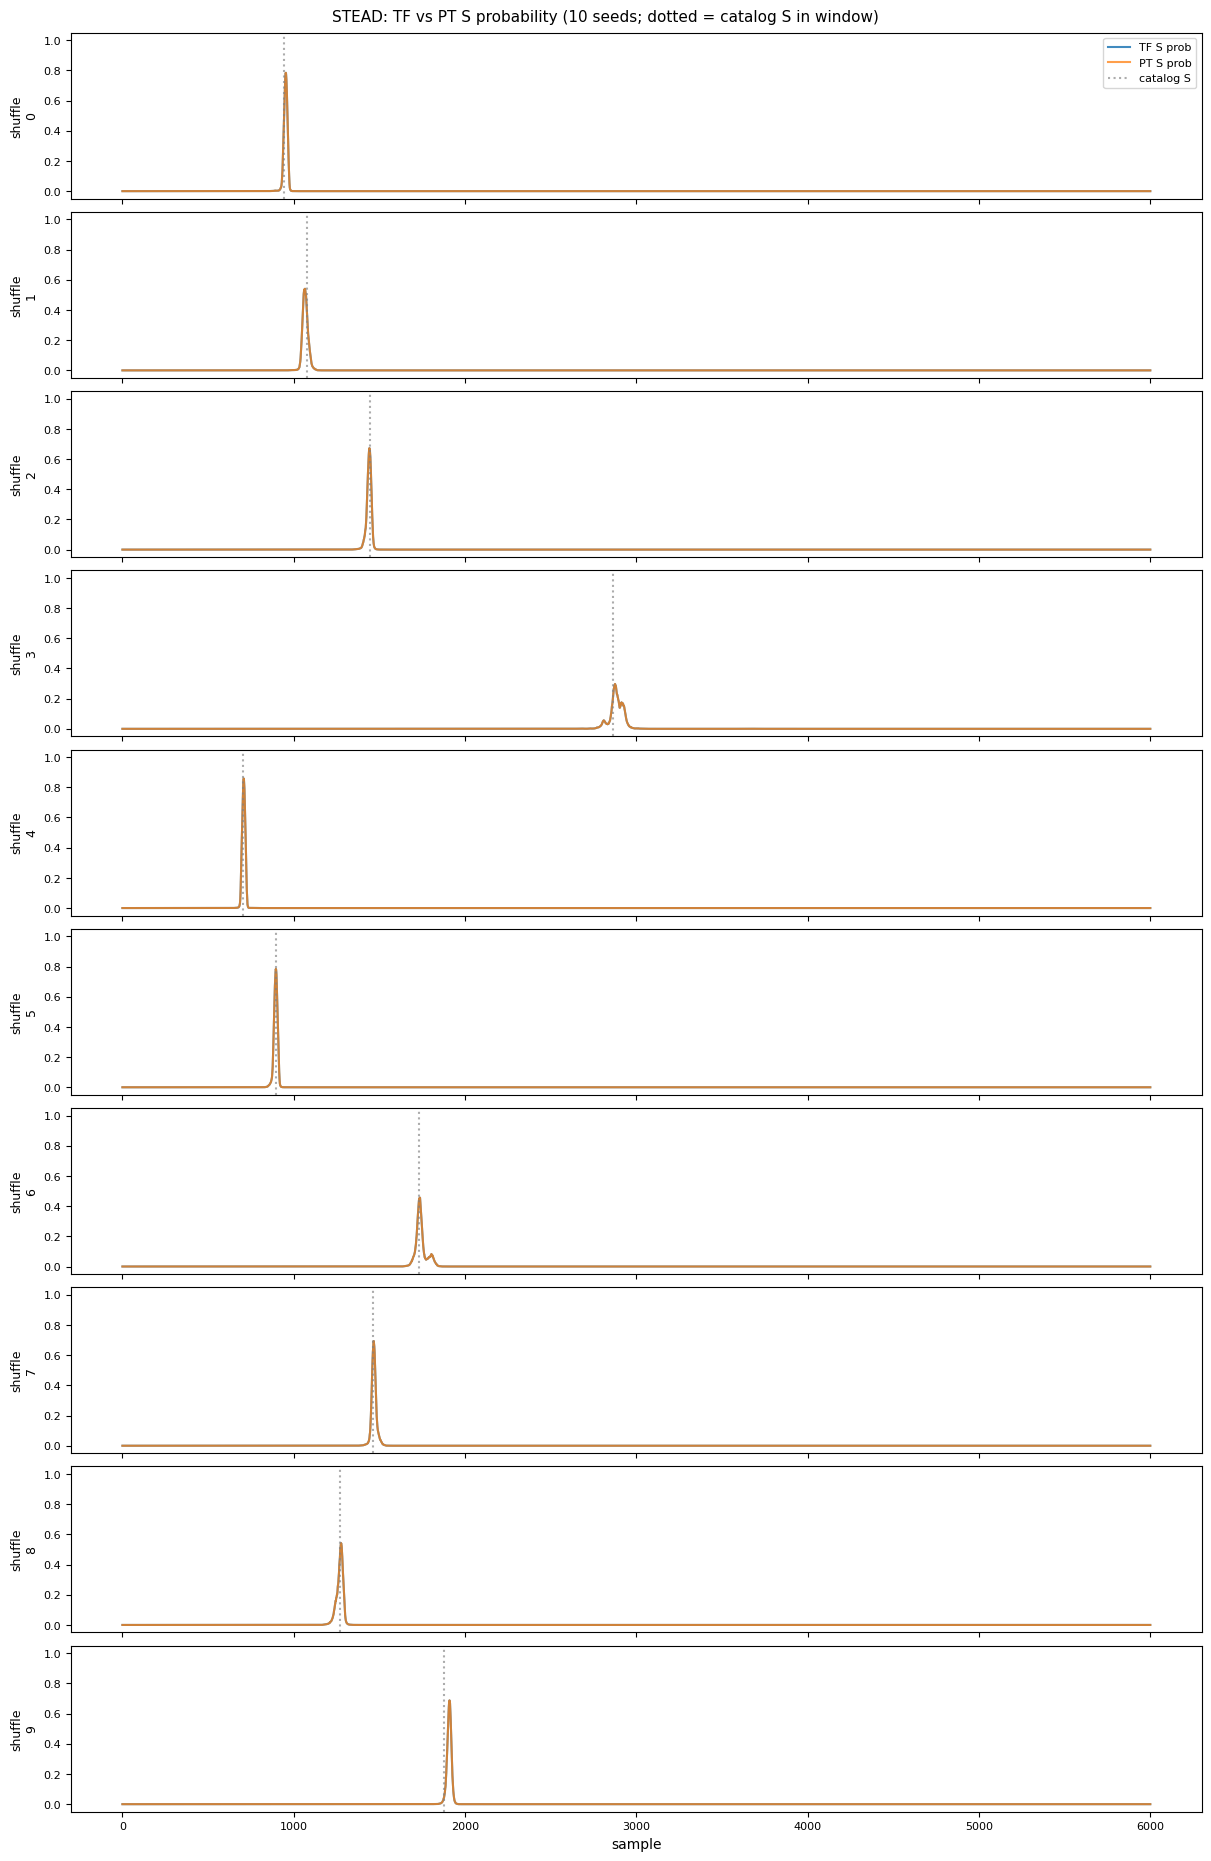

In [ ]:
rows = []
for shuffle_seed in SHUFFLE_SEEDS:
    trace_name, wf, s_in_window = window_for_shuffle_seed(shuffle_seed)
    tf_out = model_s_tf(wf, training=False)
    if hasattr(tf_out, "numpy"):
        s_tf = tf_out.numpy()
    else:
        s_tf = np.asarray(tf_out)
    if s_tf.ndim == 3:
        s_tf = s_tf[..., 0]
    with torch.no_grad():
        s_pt = model_pt(torch.from_numpy(wf)).numpy()[..., 0]
    diff = np.abs(s_tf - s_pt)
    rows.append(
        {
            "seed": shuffle_seed,
            "trace": trace_name,
            "s_cat": s_in_window,
            "s_tf": s_tf,
            "s_pt": s_pt,
            "max_diff": float(diff.max()),
            "mean_diff": float(diff.mean()),
            "argmax_tf": int(s_tf[0].argmax()),
            "argmax_pt": int(s_pt[0].argmax()),
        }
    )

for r in rows:
    print(
        f"seed {r['seed']:2d}  max|TF-PT|={r['max_diff']:.4f}  "
        f"argmax TF={r['argmax_tf']:4d} PT={r['argmax_pt']:4d}  catalog_S={r['s_cat']:4d}  {r['trace'][:48]!r}…"
    )

fig_h = max(2.0, 1.85 * N_SHUFFLE_SEEDS)
fig, axes = plt.subplots(N_SHUFFLE_SEEDS, 1, figsize=(12, fig_h), sharex=True, layout="constrained")
if N_SHUFFLE_SEEDS == 1:
    axes = [axes]
for ax, r in zip(axes, rows):
    ax.plot(r["s_tf"][0], label="TF S prob", alpha=0.85)
    ax.plot(r["s_pt"][0], label="PT S prob", alpha=0.75)
    ax.axvline(r["s_cat"], color="gray", ls=":", alpha=0.65, label="catalog S")
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(f"shuffle\n{r['seed']}", fontsize=9)
    ax.tick_params(labelsize=8)
axes[0].legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("sample")
fig.suptitle(
    f"{ds_name}: TF vs PT S probability ({N_SHUFFLE_SEEDS} seeds; dotted = catalog S in window)",
    fontsize=11,
)
plt.show()